# **Exploratory Data Analysis**

## Data pre-processing

### Imports

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [2]:
import pandas as pd
import numpy as np
import os
import random
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit
import category_encoders as ce
import joblib
import pickle

import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
RANDOM_SEED = 42

def set_seed(seed=RANDOM_SEED):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

set_seed()

### Memory reduction

In [4]:
DATA_PATH = './data/'

# function to reduce memory usage by downcasting numeric columns
def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2    
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min >= np.iinfo(np.int8).min and c_max <= np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)    
    if verbose:
        end_mem = df.memory_usage().sum() / 1024**2
        print(f'Memory usage reduced to {end_mem:.2f} Mb (Reduction of {100 * (start_mem - end_mem) / start_mem:.1f}%)')
    return df

In [5]:
# load datasets and reduce memory usage
train_transaction = pd.read_csv(os.path.join(DATA_PATH, 'train_transaction.csv'))
train_identity = pd.read_csv(os.path.join(DATA_PATH, 'train_identity.csv'))

train_transaction = reduce_mem_usage(train_transaction)
train_identity = reduce_mem_usage(train_identity)

df_train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')

Memory usage reduced to 916.30 Mb (Reduction of 48.4%)
Memory usage reduced to 31.91 Mb (Reduction of 29.3%)


In [6]:
df_train

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.500000,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.000000,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.000000,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.000000,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.000000,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.000000,W,6550,NaN,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590536,3577536,0,15811049,39.500000,W,10444,225.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590537,3577537,0,15811079,30.950001,W,12037,595.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590538,3577538,0,15811088,117.000000,W,7826,481.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
categorical_features = ['ProductCD', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain'] + \
                       [f'card{i}' for i in range(1, 7)] + \
                       [f'M{i}' for i in range(1, 10)] + \
                       ['DeviceType', 'DeviceInfo'] + \
                       [f'id_{i}' for i in range(12, 39)]

# convert categorical features to string type for encoding
for col in categorical_features:
    if col in df_train.columns:
        df_train[col] = df_train[col].astype(str)

In [8]:
# feature engineering: creating new features based on existing ones to capture more complex patterns in the data
df_train['Transaction_Cents'] = (df_train['TransactionAmt'] % 1).round(3)
df_train['Hour_of_Day'] = np.floor(df_train['TransactionDT'] / 3600) % 24
df_train['Day_of_Week'] = np.floor(df_train['TransactionDT'] / (3600 * 24)) % 7

### Exploratory Visual Analysis

Before transforming the data, I inspect the raw signal to motivate the pipeline choices. I examine: **(a)** the target class imbalance, **(b)** how transaction amounts differ between fraud and legitimate activity, **(c)–(d)** the temporal fraud patterns captured by the engineered `Hour_of_Day` and `Day_of_Week` features, and **(e)** the "cents trick" hypothesis behind `Transaction_Cents`. These plots are computed on `df_train` while the `isFraud` target is still present (before the temporal split).

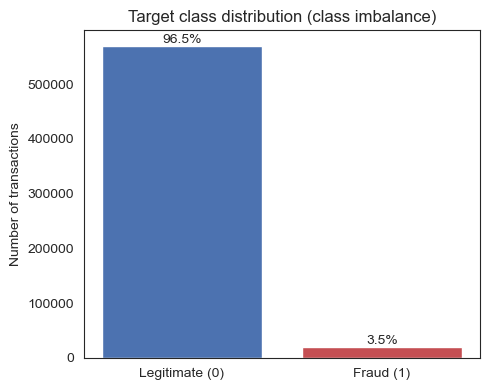

Fraud rate: 3.50% of all transactions (20,663 of 590,540)


In [9]:
sns.set_style('white')
PALETTE = ['#4C72B0', '#C44E52']  # [legitimate, fraud]

# target class distribution: quantifies the imbalance that drives every design choice
fraud_counts = df_train['isFraud'].value_counts().sort_index()
fraud_pct = df_train['isFraud'].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Legitimate (0)', 'Fraud (1)'], fraud_counts.values, color=PALETTE)
for bar, pct in zip(bars, fraud_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_title('Target class distribution (class imbalance)', fontsize=12)
ax.set_ylabel('Number of transactions')
plt.tight_layout()
plt.show()

print(f"Fraud rate: {fraud_pct[1]:.2f}% of all transactions ({fraud_counts[1]:,} of {fraud_counts.sum():,})")

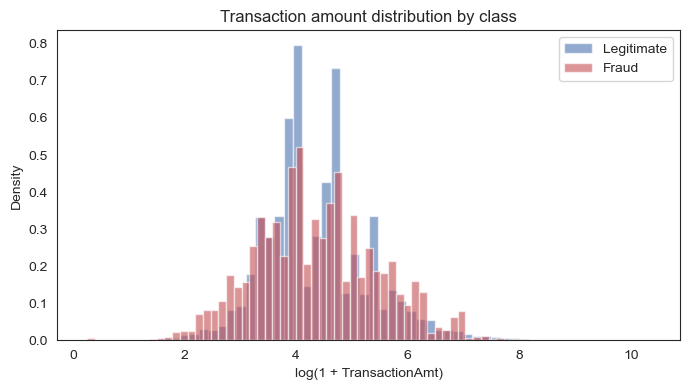

In [ ]:
# TransactionAmt distribution by class (log scale)
# log transform because amounts are heavily right-skewed reveals whether fraud favours certain value ranges
fig, ax = plt.subplots(figsize=(7, 4))
for label, color, name in [(0, PALETTE[0], 'Legitimate'), (1, PALETTE[1], 'Fraud')]:
    subset = df_train.loc[df_train['isFraud'] == label, 'TransactionAmt']
    ax.hist(np.log1p(subset), bins=60, alpha=0.6, density=True, color=color, label=name)
ax.set_title('Transaction amount distribution by class')
ax.set_xlabel('log(1 + TransactionAmt)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

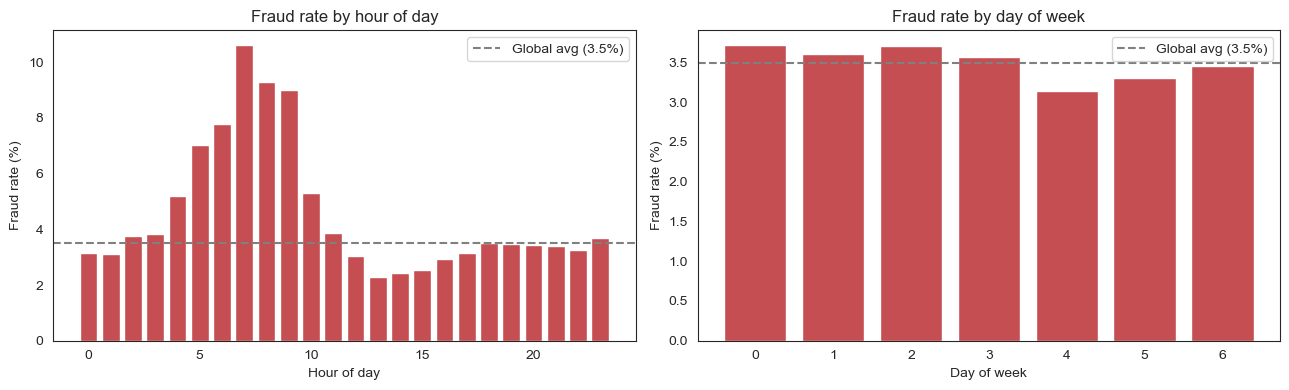

In [11]:
# fraud rate by hour of day and day of week
# validates the engineered temporal features: if fraud rate varies across time, these features carry signal
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

hourly_fraud = df_train.groupby('Hour_of_Day')['isFraud'].mean() * 100
axes[0].bar(hourly_fraud.index, hourly_fraud.values, color=PALETTE[1])
axes[0].axhline(fraud_pct[1], color='gray', ls='--', label=f'Global avg ({fraud_pct[1]:.1f}%)')
axes[0].set_title('Fraud rate by hour of day')
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Fraud rate (%)')
axes[0].legend()

dow_fraud = df_train.groupby('Day_of_Week')['isFraud'].mean() * 100
axes[1].bar(dow_fraud.index, dow_fraud.values, color=PALETTE[1])
axes[1].axhline(fraud_pct[1], color='gray', ls='--', label=f'Global avg ({fraud_pct[1]:.1f}%)')
axes[1].set_title('Fraud rate by day of week')
axes[1].set_xlabel('Day of week')
axes[1].set_ylabel('Fraud rate (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

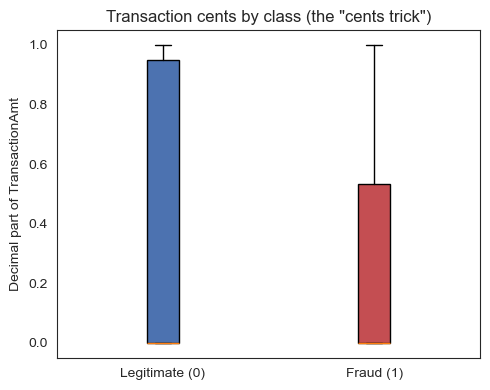

Share of round-value transactions (cents == 0) by class:
isFraud
0    51.61
1    52.66
Name: Transaction_Cents, dtype: float64


In [12]:
# Transaction_Cents by class: validates the "cents trick" hypothesis
# Fraudsters often charge round amounts, while legitimate purchases carry odd cents (tax, shipping)
fig, ax = plt.subplots(figsize=(5, 4))
data_to_plot = [df_train.loc[df_train['isFraud'] == 0, 'Transaction_Cents'],
                df_train.loc[df_train['isFraud'] == 1, 'Transaction_Cents']]
bp = ax.boxplot(data_to_plot, tick_labels=['Legitimate (0)', 'Fraud (1)'],
                patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
ax.set_title('Transaction cents by class (the "cents trick")')
ax.set_ylabel('Decimal part of TransactionAmt')
plt.tight_layout()
plt.savefig('transaction_cents_trick.png', dpi=300, bbox_inches='tight')
plt.show()

# share of perfectly round transactions (cents == 0) per class
round_share = df_train.groupby('isFraud')['Transaction_Cents'].apply(lambda s: (s == 0).mean() * 100).round(2)
print("Share of round-value transactions (cents == 0) by class:")
print(round_share)

### Train and test split

In [13]:
# train and test split based on TransactionDT to avoid data leakage
df_train = df_train.sort_values('TransactionDT')
split_idx = int(len(df_train) * 0.8)
drop_cols = ['isFraud', 'TransactionDT', 'TransactionID']

# separating features and target variable for train and test sets
X_train = df_train.drop(columns=drop_cols).iloc[:split_idx]
y_train = df_train['isFraud'].iloc[:split_idx]

X_test = df_train.drop(columns=drop_cols).iloc[split_idx:]
y_test = df_train['isFraud'].iloc[split_idx:]

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (472432, 434) | Test: (118108, 434)


### Velocity features

Fraud often occurs with cards or addresses seen rarely in the training window (cloned cards used once). Statistics are computed **only on X_train** and then mapped to X_test — preserving the temporal split and avoiding leakage.

In [14]:
velocity_maps = {}

for col in ['card1', 'addr1']:
    if col in X_train.columns:
        # frequency of each value in the training window (rare card → likely cloned)
        freq_map = X_train[col].value_counts()
        X_train[f'{col}_freq'] = X_train[col].map(freq_map).fillna(0).astype(np.float32)
        X_test[f'{col}_freq']  = X_test[col].map(freq_map).fillna(0).astype(np.float32)
        velocity_maps[f'{col}_freq'] = freq_map

        # mean transaction amount for this card/address in the training window
        amt_map = X_train.groupby(col)['TransactionAmt'].mean()
        global_mean = float(X_train['TransactionAmt'].mean())
        X_train[f'{col}_amt_mean'] = X_train[col].map(amt_map).fillna(global_mean).astype(np.float32)
        X_test[f'{col}_amt_mean']  = X_test[col].map(amt_map).fillna(global_mean).astype(np.float32)
        velocity_maps[f'{col}_amt_mean'] = amt_map

new_vel_cols = [c for c in X_train.columns if '_freq' in c or '_amt_mean' in c]
print(f"Velocity features added: {new_vel_cols}")
print(f"X_train shape after velocity features: {X_train.shape}")

Velocity features added: ['card1_freq', 'card1_amt_mean', 'addr1_freq', 'addr1_amt_mean']
X_train shape after velocity features: (472432, 438)


### Graph features

Fraud rarely acts alone: stolen cards, burner e-mail domains and shared devices form **fraud hubs**. Modelling the entities (`card1`, `P_emaildomain`, `R_emaildomain`, `DeviceInfo`, `addr1`) as nodes in a network, I extract two cheap graph signals — a node's historical **fraud rate** ("infection" score) and its **bipartite degree** (how many distinct e-mails/devices/cards it connects to). A transaction entering through a known hub gets flagged even when its amount looks legitimate.

Because the fraud rate uses the target, it is encoded **out-of-fold with `TimeSeriesSplit`** (the same guard used for the target encoder) so no training row sees its own label — otherwise singleton cards would simply memorise their outcome. The degree features are label-free and computed on the full training window. All maps are fitted **only on X_train** and mapped to X_test to preserve the temporal split.

In [ ]:
# Graph-theory features: model entities (cards, e-mails, devices) as a network and
# extract signals of "fraud hub" membership
graph_maps = {}
_global_fraud_rate = float(y_train.mean())  # fallback for entities unseen in training

fraud_rate_cols = [c for c in ['card1', 'P_emaildomain', 'R_emaildomain', 'DeviceInfo', 'addr1']
                   if c in X_train.columns]

# lightweight working frame (entity columns + label) keeps the per-fold groupby cheap
_work = X_train[fraud_rate_cols].copy()
_work['_isFraud'] = y_train  # aligned by index label

# full-train maps: applied to X_test and persisted for inference
for col in fraud_rate_cols:
    graph_maps[f'{col}_fraud_rate'] = _work.groupby(col)['_isFraud'].mean()
    X_test[f'{col}_fraud_rate'] = (
        X_test[col].map(graph_maps[f'{col}_fraud_rate']).fillna(_global_fraud_rate).astype(np.float32)
    )

# out-of-fold values for X_train itself
oof = {col: pd.Series(np.nan, index=X_train.index) for col in fraud_rate_cols}
tscv = TimeSeriesSplit(n_splits=5)
encoded_mask = np.zeros(len(X_train), dtype=bool)

for train_index, val_index in tscv.split(_work):
    fold = _work.iloc[train_index]
    val_labels = _work.index[val_index]
    for col in fraud_rate_cols:
        fold_map = fold.groupby(col)['_isFraud'].mean()
        oof[col].loc[val_labels] = _work[col].loc[val_labels].map(fold_map)
    encoded_mask[val_index] = True

# earliest rows never fall into a validation fold → fall back to the full-train map
if (~encoded_mask).any():
    initial_labels = X_train.index[~encoded_mask]
    for col in fraud_rate_cols:
        oof[col].loc[initial_labels] = _work[col].loc[initial_labels].map(graph_maps[f'{col}_fraud_rate'])

for col in fraud_rate_cols:
    X_train[f'{col}_fraud_rate'] = oof[col].fillna(_global_fraud_rate).astype(np.float32)

del _work, oof

# Bipartite node degree: label-free, so no leakage → computed on full X_train
degree_pairs = [
    ('card1',         'P_emaildomain', 'card1_n_unique_emails'),
    ('card1',         'DeviceInfo',    'card1_n_unique_devices'),
    ('P_emaildomain', 'card1',         'email_p_n_unique_cards'),
]
for source_col, target_col, feat in degree_pairs:
    if source_col in X_train.columns and target_col in X_train.columns:
        degree_map = X_train.groupby(source_col)[target_col].nunique()
        X_train[feat] = X_train[source_col].map(degree_map).fillna(0).astype(np.float32)
        X_test[feat]  = X_test[source_col].map(degree_map).fillna(0).astype(np.float32)
        graph_maps[feat] = degree_map

new_graph_cols = [c for c in X_train.columns if '_fraud_rate' in c or '_n_unique_' in c]
print(f"Graph features added (fraud rates encoded out-of-fold): {new_graph_cols}")
print(f"X_train shape after graph features: {X_train.shape}")

joblib.dump(graph_maps, 'data/graph_features.pkl')

Graph features added (fraud rates encoded out-of-fold): ['card1_fraud_rate', 'P_emaildomain_fraud_rate', 'R_emaildomain_fraud_rate', 'DeviceInfo_fraud_rate', 'addr1_fraud_rate', 'card1_n_unique_emails', 'card1_n_unique_devices', 'email_p_n_unique_cards']
X_train shape after graph features: (472432, 446)


['data/graph_features.pkl']

### Imputation and scaler transformation

In [16]:
# data preprocessing for v columns
v_cols = [f'V{i}' for i in range(1, 340) if f'V{i}' in df_train.columns]

# nan imputation using median strategy since it's more robust to outliers
imputer = SimpleImputer(strategy='median')
X_train_v_clean = imputer.fit_transform(X_train[v_cols])
X_test_v_clean = imputer.transform(X_test[v_cols])

# feature scaling using StandardScaler to ensure all features are on the same scale before PCA
scaler = StandardScaler()
X_train_v_scaled = scaler.fit_transform(X_train_v_clean)
X_test_v_scaled = scaler.transform(X_test_v_clean)

### PCA

In [17]:
# PCA for dimensionality reduction, retaining 90% of the variance to balance between information retention and noise reduction
pca = PCA(n_components=0.90, random_state=RANDOM_SEED)
X_train_v_pca = pca.fit_transform(X_train_v_scaled)
X_test_v_pca = pca.transform(X_test_v_scaled)

pca_cols = [f'v_pca_{i+1}' for i in range(X_train_v_pca.shape[1])]

# transforming PCA results into a df for better readability
df_train_v_pca = pd.DataFrame(X_train_v_pca, columns=pca_cols, index=X_train.index)
df_test_v_pca = pd.DataFrame(X_test_v_pca, columns=pca_cols, index=X_test.index)

print(f"\n--- Reduction results ---")
print(f"Original columns: {len(v_cols)}")
print(f"New columns (Components): {df_train_v_pca.shape[1]}")


--- Reduction results ---
Original columns: 339
New columns (Components): 69


In [18]:
# dropping original v columns and concatenating PCA components to the main df
X_train = X_train.drop(columns=v_cols)
X_train = pd.concat([X_train, df_train_v_pca], axis=1)

X_test = X_test.drop(columns=v_cols)
X_test = pd.concat([X_test, df_test_v_pca], axis=1)
print(f"\nDimensions after preprocessing: Train {X_train.shape} | Test {X_test.shape}")


Dimensions after preprocessing: Train (472432, 176) | Test (118108, 176)


### Categorical encoding

In [19]:
cat_cols = X_train.select_dtypes(include=['object', 'category', 'string']).columns
cardinality = X_train[cat_cols].nunique().sort_values(ascending=False)
THRESHOLD = 15
high_cardinality_cols = cardinality[cardinality > THRESHOLD].index.tolist()
low_cardinality_cols = cardinality[cardinality <= THRESHOLD].index.tolist()

In [20]:
# high_cardinality_cols = ['DeviceInfo', 'id_33', 'id_31', 'id_30', 'R_emaildomain', 'P_emaildomain']
# Out-of-fold target encoding with TimeSeriesSplit: each fold fits the encoder only on
# past rows and transforms future rows, matching the project's temporal split and avoiding
# the look-ahead leakage that a shuffled KFold would introduce on time-ordered data
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

target_encoder = ce.TargetEncoder(cols=high_cardinality_cols)
target_encoder.fit(X_train, y_train)

encoded_mask = np.zeros(len(X_train), dtype=bool)

for train_index, val_index in tscv.split(X_train):
    X_fold_train, X_fold_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_fold_train = y_train.iloc[train_index]

    fold_encoder = ce.TargetEncoder(cols=high_cardinality_cols)
    fold_encoder.fit(X_fold_train, y_fold_train)

    encoded_val = fold_encoder.transform(X_fold_val)
    X_train_encoded.loc[X_train.index[val_index], high_cardinality_cols] = encoded_val[high_cardinality_cols]
    encoded_mask[val_index] = True

if (~encoded_mask).any():
    initial_idx = X_train.index[~encoded_mask]
    encoded_initial = target_encoder.transform(X_train.loc[initial_idx])
    X_train_encoded.loc[initial_idx, high_cardinality_cols] = encoded_initial[high_cardinality_cols]

X_test_encoded[high_cardinality_cols] = target_encoder.transform(X_test)[high_cardinality_cols]

X_train = X_train_encoded
X_test = X_test_encoded

In [21]:
# for low cardinality columns, we will use one-hot encoding
# low_cardinality_cols = [col for col in cat_cols if col not in high_cardinality_cols]
onehot_encoder = ce.OneHotEncoder(cols=low_cardinality_cols, drop_invariant=True)
X_train = onehot_encoder.fit_transform(X_train)
X_test = onehot_encoder.transform(X_test)

print(f"\nFinal dataset dimensions after encoding:")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")


Final dataset dimensions after encoding:
Train: (472432, 238) | Test: (118108, 238)


In [22]:
X_train

,TransactionAmt,ProductCD_1,ProductCD_2,ProductCD_3,ProductCD_4,ProductCD_5,card1,card2,card3,card4_1,...,v_pca_60,v_pca_61,v_pca_62,v_pca_63,v_pca_64,v_pca_65,v_pca_66,v_pca_67,v_pca_68,v_pca_69
0,68.500000,1,0,0,0,0,0.21785,0.055943,0.024887,1,...,-0.206324,-0.358921,0.192428,-0.241860,0.237931,0.326471,-0.247263,-0.495078,0.103317,0.319935
1,29.000000,1,0,0,0,0,0.054386,0.07082,0.024887,0,...,0.001593,0.112218,-0.029969,-0.038180,0.018252,-0.142214,0.029139,-0.185806,-0.330811,0.193204
2,59.000000,1,0,0,0,0,0.010158,0.023701,0.024887,0,...,-0.226099,0.076267,0.054279,-0.009097,0.147737,-0.018831,-0.047890,-0.293856,-0.032063,0.037903
3,50.000000,1,0,0,0,0,0.01478,0.016041,0.024887,0,...,-0.631673,0.198444,-2.503737,-1.637676,-3.954965,1.015408,-0.725895,-1.004212,0.625933,-0.934185
4,50.000000,0,1,0,0,0,0.049001,0.047486,0.024887,0,...,0.236874,-0.291707,0.255104,0.160673,-0.411115,-0.368268,-0.667674,-0.299499,0.608236,-0.153764
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
472427,43.950001,1,0,0,0,0,0.007576,0.009136,0.025006,0,...,0.875024,0.556752,-0.618632,1.667284,-0.901548,-0.553700,-0.111332,0.087012,0.081055,-0.468746
472428,49.000000,1,0,0,0,0,0.030663,0.027356,0.025006,0,...,0.236425,-1.228491,0.774734,1.178179,-0.431410,0.641492,0.816133,-0.623217,-0.638071,-0.118083
472429,40.000000,0,1,0,0,0,0.020524,0.03138,0.025006,0,...,0.375243,-0.235042,0.041239,-0.309178,0.001688,0.256521,0.228685,0.714674,-0.438894,0.069237
472430,15.000000,1,0,0,0,0,0.008759,0.009054,0.025006,0,...,-0.127300,-0.151547,-0.109479,0.193830,-0.291314,-0.050735,-0.265059,-0.295541,0.246314,0.197572


In [23]:
print(df_train_v_pca.shape[1])

69


In [ ]:
X_train.to_parquet('data/X_train_final.parquet')
X_test.to_parquet('data/X_test_final.parquet')
y_train.to_frame().to_parquet('data/y_train_final.parquet')
y_test.to_frame().to_parquet('data/y_test_final.parquet')

joblib.dump(imputer, 'data/imputer_v_cols.pkl')
joblib.dump(scaler, 'data/scaler_v_cols.pkl')
joblib.dump(pca, 'data/pca_v_cols.pkl')
joblib.dump(target_encoder, 'data/target_encoder.pkl')
joblib.dump(onehot_encoder, 'data/onehot_encoder.pkl')
joblib.dump(velocity_maps, 'data/velocity_maps.pkl')

with open('data/train_columns.pkl', 'wb') as f:
    pickle.dump(X_train.columns.tolist(), f)